# EXPLORATORY DATA ANALYSIS (EDA)
# Kelembaban Tanah Volumetrik vs Reflektansi Band Sentinel-2
# 4 Skenario: MLR_A, MLR_B, RF_A, RF_B

In [1]:
# -----------------------------------------------------------------------------
# MOUNT GOOGLE DRIVE
# -----------------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# -----------------------------------------------------------------------------
# ⚙️  KONFIGURASI PATH — SESUAIKAN DENGAN LOKASI FILE DI DRIVE-MU
# -----------------------------------------------------------------------------
# Contoh: jika file CSV ada di "My Drive/Skripsi/Data/"
# maka INPUT_DIR = "/content/drive/My Drive/Skripsi/Data/"

INPUT_DIR  = "/content/drive/MyDrive/Kelembaban_Lapang/Input/"          # ← folder tempat CSV-mu
OUTPUT_DIR = "/content/drive/MyDrive/Kelembaban_Lapang/EDA/" # ← folder output plot & ringkasan

# Nama file (jangan ubah kecuali nama file-mu berbeda)
FILE_LAPANGAN  = "Hasil_Lapangan.csv"
FILE_KELOMPOK_A = "kelompokA_10m_Mei2026_modified.csv"
FILE_KELOMPOK_B = "kelompokB_20m_Mei2026.csv"

# Buat folder output jika belum ada
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output akan disimpan ke: {OUTPUT_DIR}")

✓ Output akan disimpan ke: /content/drive/MyDrive/Kelembaban_Lapang/EDA/


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
sns.set_palette("husl")

print("=" * 65)
print("  EDA — KELEMBABAN TANAH vs REFLEKTANSI SENTINEL-2")
print("=" * 65)

  EDA — KELEMBABAN TANAH vs REFLEKTANSI SENTINEL-2


In [4]:
# =============================================================================
# BAGIAN 0: LOAD & MERGE DATA
# =============================================================================
print("\n[0] LOAD DAN MERGE DATA")
print("-" * 40)

df_lapangan = pd.read_csv(INPUT_DIR + FILE_LAPANGAN)
df_A        = pd.read_csv(INPUT_DIR + FILE_KELOMPOK_A)
df_B        = pd.read_csv(INPUT_DIR + FILE_KELOMPOK_B)

print(f"  Lapangan   : {df_lapangan.shape[0]} baris, {df_lapangan.shape[1]} kolom")
print(f"  Kelompok A : {df_A.shape[0]} baris, {df_A.shape[1]} kolom")
print(f"  Kelompok B : {df_B.shape[0]} baris, {df_B.shape[1]} kolom")

df_merge_A = df_lapangan.merge(
    df_A[['fid', 'B2', 'B3', 'B4', 'B8']],
    on='fid', how='inner'
)
df_merge_B = df_lapangan.merge(
    df_B[['fid', 'B5', 'B6', 'B7', 'B8A', 'B11', 'B12', 'NSMI_SWIR']],
    on='fid', how='inner'
)

band_cols_A = ['B2', 'B3', 'B4', 'B8']
band_cols_B = ['B5', 'B6', 'B7', 'B8A', 'B11', 'B12']
y_col       = 'Kelembaban (%)'

print(f"\n  Setelah merge:")
print(f"  Dataset A (10m) : {df_merge_A.shape[0]} sampel valid")
print(f"  Dataset B (20m) : {df_merge_B.shape[0]} sampel valid")

fid_lapangan = set(df_lapangan['fid'])
fid_sentinel = set(df_A['fid'])
fid_hilang   = sorted(fid_lapangan - fid_sentinel)

print(f"\n  ⚠ PERHATIAN: {len(fid_hilang)} titik lapangan TIDAK ADA di data Sentinel-2")
print(f"    fid yang hilang: {fid_hilang}")
print("    → Investigasi penyebabnya sebelum sidang (cloud cover? koordinat miss?)")


[0] LOAD DAN MERGE DATA
----------------------------------------
  Lapangan   : 49 baris, 7 kolom
  Kelompok A : 42 baris, 9 kolom
  Kelompok B : 42 baris, 12 kolom

  Setelah merge:
  Dataset A (10m) : 42 sampel valid
  Dataset B (20m) : 42 sampel valid

  ⚠ PERHATIAN: 7 titik lapangan TIDAK ADA di data Sentinel-2
    fid yang hilang: [18, 25, 29, 40, 43, 46, 49]
    → Investigasi penyebabnya sebelum sidang (cloud cover? koordinat miss?)


In [5]:
# =============================================================================
# BAGIAN 1: STATISTIK DESKRIPTIF
# =============================================================================
print("\n\n[1] STATISTIK DESKRIPTIF")
print("-" * 40)

print("\n  [1a] Variabel Dependen — Kelembaban Tanah (%)")
y_all = df_lapangan[y_col]
desc_y = y_all.describe()
skewness = y_all.skew()
kurtosis = y_all.kurtosis()

print(f"    N         : {int(desc_y['count'])}")
print(f"    Mean      : {desc_y['mean']:.2f}%")
print(f"    Median    : {desc_y['50%']:.2f}%")
print(f"    Std Dev   : {desc_y['std']:.2f}%")
print(f"    Min       : {desc_y['min']:.2f}%")
print(f"    Max       : {desc_y['max']:.2f}%")
print(f"    Skewness  : {skewness:.3f}  {'(negatif/left-skewed)' if skewness < -0.5 else '(positif/right-skewed)' if skewness > 0.5 else '(mendekati simetris)'}")
print(f"    Kurtosis  : {kurtosis:.3f}")

if abs(skewness) < 0.5:
    print("    → Distribusi Y mendekati normal. Asumsi MLR lebih mudah terpenuhi.")
elif abs(skewness) < 1.0:
    print("    → Distribusi Y sedikit miring. Cek uji normalitas sebelum MLR.")
else:
    print("    → Distribusi Y sangat miring. Pertimbangkan transformasi (log/sqrt) untuk MLR.")

print("\n  [1b] Variabel Independen — Band Kelompok A (10m)")
desc_A = df_merge_A[band_cols_A].describe().T
desc_A['skewness'] = df_merge_A[band_cols_A].skew()
print(desc_A[['count','mean','std','min','max','skewness']].round(4).to_string())

print("\n  [1c] Variabel Independen — Band Kelompok B (20m)")
desc_B = df_merge_B[band_cols_B].describe().T
desc_B['skewness'] = df_merge_B[band_cols_B].skew()
print(desc_B[['count','mean','std','min','max','skewness']].round(4).to_string())



[1] STATISTIK DESKRIPTIF
----------------------------------------

  [1a] Variabel Dependen — Kelembaban Tanah (%)
    N         : 43
    Mean      : 73.72%
    Median    : 76.60%
    Std Dev   : 15.31%
    Min       : 34.90%
    Max       : 94.90%
    Skewness  : -1.021  (negatif/left-skewed)
    Kurtosis  : 0.802
    → Distribusi Y sangat miring. Pertimbangkan transformasi (log/sqrt) untuk MLR.

  [1b] Variabel Independen — Band Kelompok A (10m)
    count    mean     std     min     max  skewness
B2   42.0  0.0590  0.0206  0.0137  0.0950   -0.4126
B3   42.0  0.0880  0.0173  0.0520  0.1306   -0.0056
B4   42.0  0.1036  0.0248  0.0365  0.1483   -0.4799
B8   42.0  0.2197  0.0467  0.1093  0.3347   -0.0147

  [1c] Variabel Independen — Band Kelompok B (20m)
     count    mean     std     min     max  skewness
B5    42.0  0.1503  0.0225  0.1110  0.2013    0.0898
B6    42.0  0.1894  0.0337  0.1214  0.2673   -0.1282
B7    42.0  0.2155  0.0416  0.1321  0.3251   -0.0073
B8A   42.0  0.2401  0.

In [6]:
# =============================================================================
# BAGIAN 2: MISSING VALUES
# =============================================================================
print("\n\n[2] MISSING VALUES")
print("-" * 40)

for name, df in [("Lapangan", df_lapangan),
                 ("Kelompok A", df_merge_A),
                 ("Kelompok B", df_merge_B)]:
    total_missing = df.isnull().sum().sum()
    print(f"  {name}: total missing = {total_missing}")
    if total_missing > 0:
        print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n  ℹ Sampel tidak match (n=7) diperlakukan sebagai data hilang struktural,")
print("    bukan missing acak. Wajib dibahas di bagian keterbatasan penelitian.")



[2] MISSING VALUES
----------------------------------------
  Lapangan: total missing = 29
Kelembaban (%)     6
Dokumentasi       23
dtype: int64
  Kelompok A: total missing = 22
Dokumentasi    22
dtype: int64
  Kelompok B: total missing = 22
Dokumentasi    22
dtype: int64

  ℹ Sampel tidak match (n=7) diperlakukan sebagai data hilang struktural,
    bukan missing acak. Wajib dibahas di bagian keterbatasan penelitian.


In [7]:
# =============================================================================
# BAGIAN 3: UJI NORMALITAS — Shapiro-Wilk
# =============================================================================
print("\n\n[3] UJI NORMALITAS — Shapiro-Wilk")
print("-" * 40)
print("  (Shapiro-Wilk digunakan karena n < 50, lebih powerful dari K-S)")
print()

stat_y, p_y = stats.shapiro(df_lapangan[y_col].dropna())
print(f"  Kelembaban (%) — W={stat_y:.4f}, p={p_y:.4f}")
if p_y > 0.05:
    print("    → Tidak ada bukti penyimpangan normalitas (p > 0.05)")
    print("    → Asumsi normalitas Y untuk MLR terpenuhi")
else:
    print("    → Distribusi signifikan tidak normal (p ≤ 0.05)")
    print("    → Pertimbangkan transformasi data atau gunakan metode non-parametrik")

print()
for band in band_cols_A:
    stat, p = stats.shapiro(df_merge_A[band].dropna())
    status = "Normal ✓" if p > 0.05 else "TIDAK Normal ✗"
    print(f"  {band:5s} (10m) — W={stat:.4f}, p={p:.4f} → {status}")

print()
band_cols_B_norm = band_cols_B + (["NSMI_SWIR"] if "NSMI_SWIR" in df_merge_B.columns else [])
for band in band_cols_B_norm:
    stat, p = stats.shapiro(df_merge_B[band].dropna())
    status = "Normal ✓" if p > 0.05 else "TIDAK Normal ✗"
    print(f"  {band:5s} (20m) — W={stat:.4f}, p={p:.4f} → {status}")



[3] UJI NORMALITAS — Shapiro-Wilk
----------------------------------------
  (Shapiro-Wilk digunakan karena n < 50, lebih powerful dari K-S)

  Kelembaban (%) — W=0.9107, p=0.0027
    → Distribusi signifikan tidak normal (p ≤ 0.05)
    → Pertimbangkan transformasi data atau gunakan metode non-parametrik

  B2    (10m) — W=0.9379, p=0.0241 → TIDAK Normal ✗
  B3    (10m) — W=0.9821, p=0.7415 → Normal ✓
  B4    (10m) — W=0.9736, p=0.4317 → Normal ✓
  B8    (10m) — W=0.9904, p=0.9750 → Normal ✓

  B5    (20m) — W=0.9773, p=0.5606 → Normal ✓
  B6    (20m) — W=0.9743, p=0.4548 → Normal ✓
  B7    (20m) — W=0.9787, p=0.6127 → Normal ✓
  B8A   (20m) — W=0.9711, p=0.3601 → Normal ✓
  B11   (20m) — W=0.9331, p=0.0165 → TIDAK Normal ✗
  B12   (20m) — W=0.9379, p=0.0242 → TIDAK Normal ✗
  NSMI_SWIR (20m) — W=0.9575, p=0.1204 → Normal ✓


In [8]:
# =============================================================================
# BAGIAN 4: DETEKSI OUTLIER — Metode IQR
# =============================================================================
print("\n\n[4] DETEKSI OUTLIER — Metode IQR")
print("-" * 40)

def deteksi_outlier_iqr(series, nama):
    Q1   = series.quantile(0.25)
    Q3   = series.quantile(0.75)
    IQR  = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    outliers    = series[(series < batas_bawah) | (series > batas_atas)]
    print(f"  {nama:12s}: Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f} "
          f"→ Batas [{batas_bawah:.3f}, {batas_atas:.3f}] "
          f"→ Outlier: {len(outliers)} titik "
          f"{list(outliers.index) if len(outliers) > 0 else ''}")
    return outliers

print("\n  Variabel Y:")
outlier_y = deteksi_outlier_iqr(df_lapangan[y_col], "Kelembaban")

print("\n  Band Kelompok A:")
for band in band_cols_A:
    deteksi_outlier_iqr(df_merge_A[band], band)

print("\n  Band Kelompok B:")
band_cols_B_outlier = band_cols_B + (["NSMI_SWIR"] if "NSMI_SWIR" in df_merge_B.columns else [])
for band in band_cols_B_outlier:
    deteksi_outlier_iqr(df_merge_B[band], band)

print("\n  ⚠ Outlier JANGAN langsung dihapus. Investigasi apakah:")
print("    1. Error pengukuran sensor TDR di lapangan")
print("    2. Piksel Sentinel-2 terkontaminasi awan tipis")
print("    3. Kondisi tanah ekstrem yang memang nyata")



[4] DETEKSI OUTLIER — Metode IQR
----------------------------------------

  Variabel Y:
  Kelembaban  : Q1=69.450, Q3=83.250, IQR=13.800 → Batas [48.750, 103.950] → Outlier: 4 titik [8, 9, 10, 38]

  Band Kelompok A:
  B2          : Q1=0.040, Q3=0.074, IQR=0.034 → Batas [-0.010, 0.125] → Outlier: 0 titik 
  B3          : Q1=0.074, Q3=0.103, IQR=0.028 → Batas [0.032, 0.145] → Outlier: 0 titik 
  B4          : Q1=0.087, Q3=0.116, IQR=0.029 → Batas [0.043, 0.160] → Outlier: 1 titik [32]
  B8          : Q1=0.186, Q3=0.250, IQR=0.064 → Batas [0.090, 0.346] → Outlier: 0 titik 

  Band Kelompok B:
  B5          : Q1=0.137, Q3=0.168, IQR=0.031 → Batas [0.090, 0.215] → Outlier: 0 titik 
  B6          : Q1=0.169, Q3=0.205, IQR=0.035 → Batas [0.116, 0.258] → Outlier: 1 titik [32]
  B7          : Q1=0.191, Q3=0.236, IQR=0.045 → Batas [0.124, 0.303] → Outlier: 1 titik [32]
  B8A         : Q1=0.210, Q3=0.275, IQR=0.064 → Batas [0.114, 0.371] → Outlier: 1 titik [32]
  B11         : Q1=0.178, Q3=0.

In [9]:
# =============================================================================
# BAGIAN 5: KORELASI BAND vs KELEMBABAN (Pearson & Spearman)
# =============================================================================
print("\n\n[5] KORELASI BAND vs KELEMBABAN (Pearson & Spearman)")
print("-" * 40)

print("\n  Kelompok A (10m):")
for band in band_cols_A:
    r_p, p_p = stats.pearsonr(df_merge_A[band], df_merge_A[y_col])
    r_s, p_s = stats.spearmanr(df_merge_A[band], df_merge_A[y_col])
    sig_p = "sig*" if p_p < 0.05 else "ns"
    sig_s = "sig*" if p_s < 0.05 else "ns"
    print(f"  {band}: Pearson r={r_p:+.3f}({sig_p})  Spearman ρ={r_s:+.3f}({sig_s})")

band_cols_B_full_5 = band_cols_B + (["NSMI_SWIR"] if "NSMI_SWIR" in df_merge_B.columns else [])
print(f"\n  Kelompok B (20m, termasuk NSMI_SWIR jika tersedia — {len(band_cols_B_full_5)} variabel):")
for band in band_cols_B_full_5:
    r_p, p_p = stats.pearsonr(df_merge_B[band], df_merge_B[y_col])
    r_s, p_s = stats.spearmanr(df_merge_B[band], df_merge_B[y_col])
    sig_p = "sig*" if p_p < 0.05 else "ns"
    sig_s = "sig*" if p_s < 0.05 else "ns"
    print(f"  {band}: Pearson r={r_p:+.3f}({sig_p})  Spearman ρ={r_s:+.3f}({sig_s})")

print("\n  Catatan: sig* = p < 0.05, ns = tidak signifikan")
print("  Perbedaan besar antara Pearson dan Spearman → hubungan non-linear")



[5] KORELASI BAND vs KELEMBABAN (Pearson & Spearman)
----------------------------------------

  Kelompok A (10m):
  B2: Pearson r=-0.560(sig*)  Spearman ρ=-0.586(sig*)
  B3: Pearson r=-0.575(sig*)  Spearman ρ=-0.553(sig*)
  B4: Pearson r=-0.142(ns)  Spearman ρ=-0.233(ns)
  B8: Pearson r=-0.052(ns)  Spearman ρ=+0.047(ns)

  Kelompok B (20m, termasuk NSMI_SWIR jika tersedia — 7 variabel):
  B5: Pearson r=-0.082(ns)  Spearman ρ=-0.067(ns)
  B6: Pearson r=-0.051(ns)  Spearman ρ=+0.060(ns)
  B7: Pearson r=-0.042(ns)  Spearman ρ=+0.064(ns)
  B8A: Pearson r=+0.016(ns)  Spearman ρ=+0.117(ns)
  B11: Pearson r=+0.062(ns)  Spearman ρ=+0.010(ns)
  B12: Pearson r=+0.048(ns)  Spearman ρ=-0.013(ns)
  NSMI_SWIR: Pearson r=+0.025(ns)  Spearman ρ=+0.044(ns)

  Catatan: sig* = p < 0.05, ns = tidak signifikan
  Perbedaan besar antara Pearson dan Spearman → hubungan non-linear


In [10]:
# BAGIAN 5B: ANALISIS KORELASI LANJUTAN

print("\n\n[5B] ANALISIS KORELASI LANJUTAN")
print("-" * 40)

from scipy.stats import t as t_dist
import scipy.stats as stats_mod



[5B] ANALISIS KORELASI LANJUTAN
----------------------------------------


In [11]:
# -----------------------------------------------------------------------------
# 5B-1. CONFIDENCE INTERVAL 95% UNTUK KORELASI PEARSON (Fisher z-transform)
# -----------------------------------------------------------------------------

print("\n  [5B-1] Confidence Interval 95% — Korelasi Pearson (Fisher z-transform)")
print("  (n=42 → CI penting karena r tidak stabil pada sampel kecil)\n")

def pearson_ci_95(r, n):
    if abs(r) == 1.0:
        return (r, r)
    z     = np.arctanh(r)
    se    = 1.0 / np.sqrt(n - 3)
    z_lo  = z - 1.96 * se
    z_hi  = z + 1.96 * se
    return (np.tanh(z_lo), np.tanh(z_hi))

ci_rows = []

print("  Kelompok A (10m):")
for band in band_cols_A:
    r_p, p_p = stats.pearsonr(df_merge_A[band], df_merge_A[y_col])
    n        = df_merge_A[[band, y_col]].dropna().shape[0]
    lo, hi   = pearson_ci_95(r_p, n)
    sig      = "sig*" if p_p < 0.05 else "ns"
    print(f"  {band:5s}: r={r_p:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]  p={p_p:.4f} ({sig})")
    ci_rows.append({'Band': band, 'Kelompok': 'A (10m)', 'n': n,
                    'Pearson_r': round(r_p,4), 'CI_low': round(lo,4),
                    'CI_high': round(hi,4), 'p_value': round(p_p,4),
                    'Signifikan': sig})

print("\n  Kelompok B (20m):")
band_cols_B_full = ['B5', 'B6', 'B7', 'B8A', 'B11', 'B12', 'NSMI_SWIR']
for band in band_cols_B_full:
    if band not in df_merge_B.columns:
        print(f"  {band:10s}: kolom tidak ditemukan — skip")
        continue
    r_p, p_p = stats.pearsonr(df_merge_B[band], df_merge_B[y_col])
    n        = df_merge_B[[band, y_col]].dropna().shape[0]
    lo, hi   = pearson_ci_95(r_p, n)
    sig      = "sig*" if p_p < 0.05 else "ns"
    print(f"  {band:10s}: r={r_p:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]  p={p_p:.4f} ({sig})")
    ci_rows.append({'Band': band, 'Kelompok': 'B (20m)', 'n': n,
                    'Pearson_r': round(r_p,4), 'CI_low': round(lo,4),
                    'CI_high': round(hi,4), 'p_value': round(p_p,4),
                    'Signifikan': sig})

df_ci = pd.DataFrame(ci_rows)
print("\n  Catatan: CI yang lebar (>0.5) = estimasi r tidak stabil → wajib dilaporkan")
print("  sebagai limitasi penelitian (konsekuensi n=42)")


  [5B-1] Confidence Interval 95% — Korelasi Pearson (Fisher z-transform)
  (n=42 → CI penting karena r tidak stabil pada sampel kecil)

  Kelompok A (10m):
  B2   : r=-0.560  95% CI [-0.738, -0.309]  p=0.0001 (sig*)
  B3   : r=-0.575  95% CI [-0.748, -0.329]  p=0.0001 (sig*)
  B4   : r=-0.142  95% CI [-0.427, +0.170]  p=0.3708 (ns)
  B8   : r=-0.052  95% CI [-0.350, +0.256]  p=0.7448 (ns)

  Kelompok B (20m):
  B5        : r=-0.082  95% CI [-0.377, +0.227]  p=0.6043 (ns)
  B6        : r=-0.051  95% CI [-0.350, +0.257]  p=0.7475 (ns)
  B7        : r=-0.042  95% CI [-0.342, +0.265]  p=0.7908 (ns)
  B8A       : r=+0.016  95% CI [-0.289, +0.319]  p=0.9178 (ns)
  B11       : r=+0.062  95% CI [-0.247, +0.359]  p=0.6971 (ns)
  B12       : r=+0.048  95% CI [-0.260, +0.347]  p=0.7632 (ns)
  NSMI_SWIR : r=+0.025  95% CI [-0.281, +0.327]  p=0.8740 (ns)

  Catatan: CI yang lebar (>0.5) = estimasi r tidak stabil → wajib dilaporkan
  sebagai limitasi penelitian (konsekuensi n=42)


In [12]:
# -----------------------------------------------------------------------------
# 5B-2. UJI LINEARITAS EKSPLISIT
# -----------------------------------------------------------------------------

print("\n\n  [5B-2] Uji Linearitas vs Non-Linearitas")
print("  Metode: Bandingkan R² linear vs R² polinomial orde-2 (kuadratik)")
print("  Interpretasi: jika R²_kuadratik >> R²_linear → hubungan non-linear\n")

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

def uji_linearitas(df_data, band, y_col, label):
    x = df_data[[band]].dropna()
    y_vals = df_data.loc[x.index, y_col]
    lr = LinearRegression().fit(x, y_vals)
    r2_lin = r2_score(y_vals, lr.predict(x))
    poly = PolynomialFeatures(degree=2, include_bias=False)
    x_poly = poly.fit_transform(x)
    lr2 = LinearRegression().fit(x_poly, y_vals)
    r2_quad = r2_score(y_vals, lr2.predict(x_poly))
    delta = r2_quad - r2_lin
    verdict = "NON-LINEAR ⚠" if delta > 0.05 else "Linear ✓"
    print(f"  {label:12s} {band:10s}: R²_lin={r2_lin:.3f}  R²_quad={r2_quad:.3f}  Δ={delta:+.3f}  → {verdict}")
    return {'Band': band, 'Kelompok': label, 'R2_linear': round(r2_lin,4),
            'R2_kuadratik': round(r2_quad,4), 'Delta_R2': round(delta,4),
            'Verdict': verdict}

lin_rows = []
print("  Kelompok A (10m):")
for band in band_cols_A:
    lin_rows.append(uji_linearitas(df_merge_A, band, y_col, "A (10m)"))

print("\n  Kelompok B (20m):")
for band in band_cols_B_full:
    if band not in df_merge_B.columns:
        continue
    lin_rows.append(uji_linearitas(df_merge_B, band, y_col, "B (20m)"))

df_linearitas = pd.DataFrame(lin_rows)
print("\n  ⚠ Band dengan Δ > 0.05: pertimbangkan transformasi atau gunakan RF yang")
print("    secara otomatis menangkap non-linearitas.")



  [5B-2] Uji Linearitas vs Non-Linearitas
  Metode: Bandingkan R² linear vs R² polinomial orde-2 (kuadratik)
  Interpretasi: jika R²_kuadratik >> R²_linear → hubungan non-linear

  Kelompok A (10m):
  A (10m)      B2        : R²_lin=0.314  R²_quad=0.316  Δ=+0.002  → Linear ✓
  A (10m)      B3        : R²_lin=0.331  R²_quad=0.346  Δ=+0.015  → Linear ✓
  A (10m)      B4        : R²_lin=0.020  R²_quad=0.021  Δ=+0.001  → Linear ✓
  A (10m)      B8        : R²_lin=0.003  R²_quad=0.006  Δ=+0.003  → Linear ✓

  Kelompok B (20m):
  B (20m)      B5        : R²_lin=0.007  R²_quad=0.007  Δ=+0.000  → Linear ✓
  B (20m)      B6        : R²_lin=0.003  R²_quad=0.006  Δ=+0.003  → Linear ✓
  B (20m)      B7        : R²_lin=0.002  R²_quad=0.009  Δ=+0.007  → Linear ✓
  B (20m)      B8A       : R²_lin=0.000  R²_quad=0.013  Δ=+0.013  → Linear ✓
  B (20m)      B11       : R²_lin=0.004  R²_quad=0.005  Δ=+0.001  → Linear ✓
  B (20m)      B12       : R²_lin=0.002  R²_quad=0.005  Δ=+0.003  → Linear ✓
  B (20m



  [5B-3] Membuat plot korelasi band vs Y...


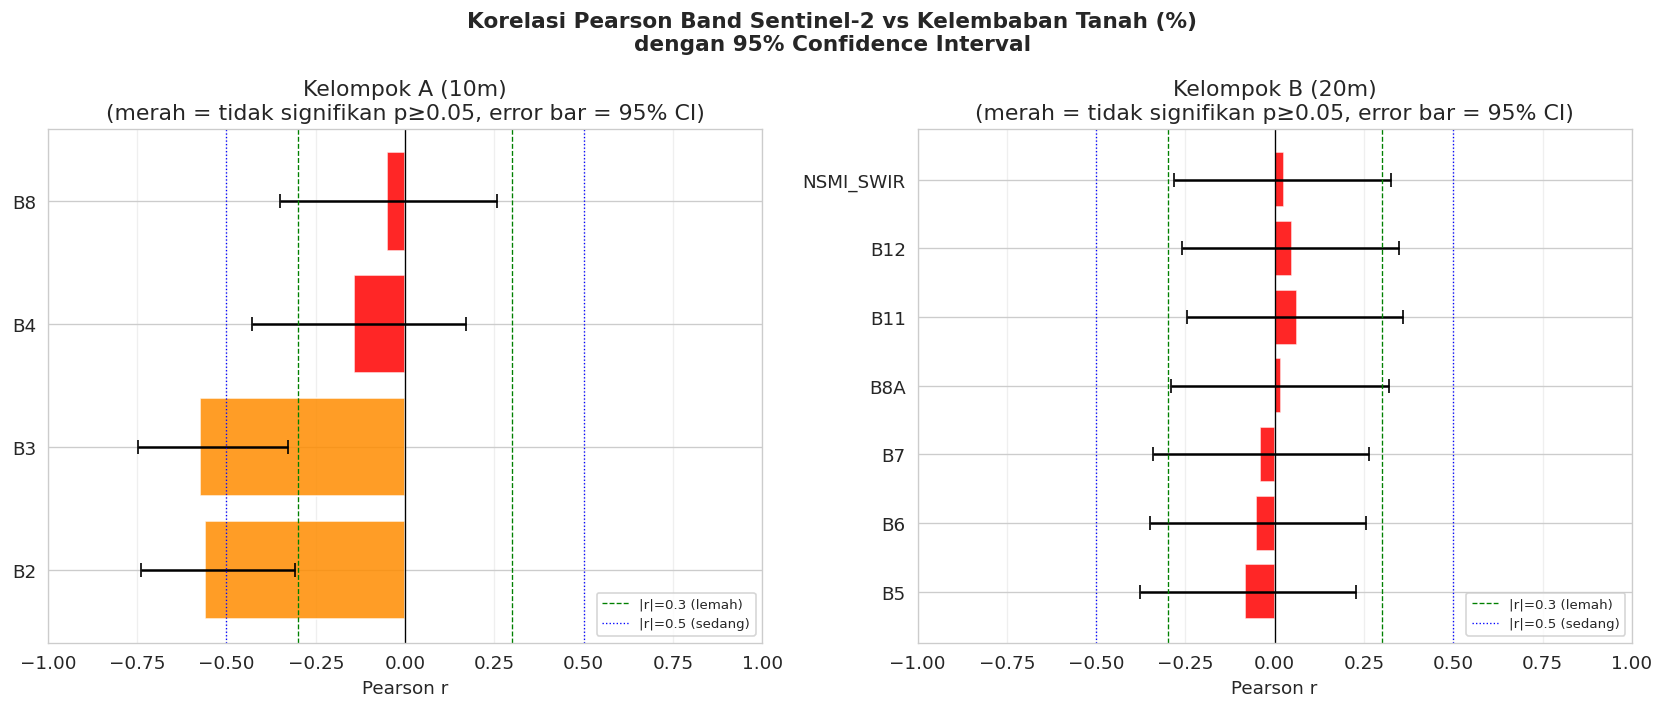

  Tersimpan: plot5B_korelasi_band_vs_Y.png


In [13]:
# -----------------------------------------------------------------------------
# 5B-3. PLOT: Heatmap Korelasi Band vs Y
# -----------------------------------------------------------------------------

print("\n\n  [5B-3] Membuat plot korelasi band vs Y...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Korelasi Pearson Band Sentinel-2 vs Kelembaban Tanah (%)\ndengan 95% Confidence Interval",
             fontsize=13, fontweight='bold')

for ax, kelompok, band_list, df_data, warna in [
    (axes[0], "Kelompok A (10m)", band_cols_A, df_merge_A, 'steelblue'),
    (axes[1], "Kelompok B (20m)", band_cols_B_full, df_merge_B, 'coral')
]:
    rs, lows, highs, labels, colors_bar = [], [], [], [], []
    for band in band_list:
        if band not in df_data.columns:
            continue
        r_p, p_p = stats.pearsonr(df_data[band], df_data[y_col])
        n        = df_data[[band, y_col]].dropna().shape[0]
        lo, hi   = pearson_ci_95(r_p, n)
        rs.append(r_p)
        lows.append(r_p - lo)
        highs.append(hi - r_p)
        labels.append(band)
        colors_bar.append('red' if p_p >= 0.05 else (warna if r_p >= 0 else 'darkorange'))

    y_pos = np.arange(len(labels))
    ax.barh(y_pos, rs, xerr=[lows, highs], align='center',
            color=colors_bar, edgecolor='white', alpha=0.85,
            error_kw=dict(elinewidth=1.5, ecolor='black', capsize=4))
    ax.axvline(0,    color='black', linewidth=0.8)
    ax.axvline(0.3,  color='green', linewidth=0.8, linestyle='--', label='|r|=0.3 (lemah)')
    ax.axvline(-0.3, color='green', linewidth=0.8, linestyle='--')
    ax.axvline(0.5,  color='blue',  linewidth=0.8, linestyle=':', label='|r|=0.5 (sedang)')
    ax.axvline(-0.5, color='blue',  linewidth=0.8, linestyle=':')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlim(-1, 1)
    ax.set_xlabel("Pearson r")
    ax.set_title(f"{kelompok}\n(merah = tidak signifikan p≥0.05, error bar = 95% CI)")
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot5B_korelasi_band_vs_Y.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot5B_korelasi_band_vs_Y.png")


  [5B-4] Membuat plot uji linearitas...


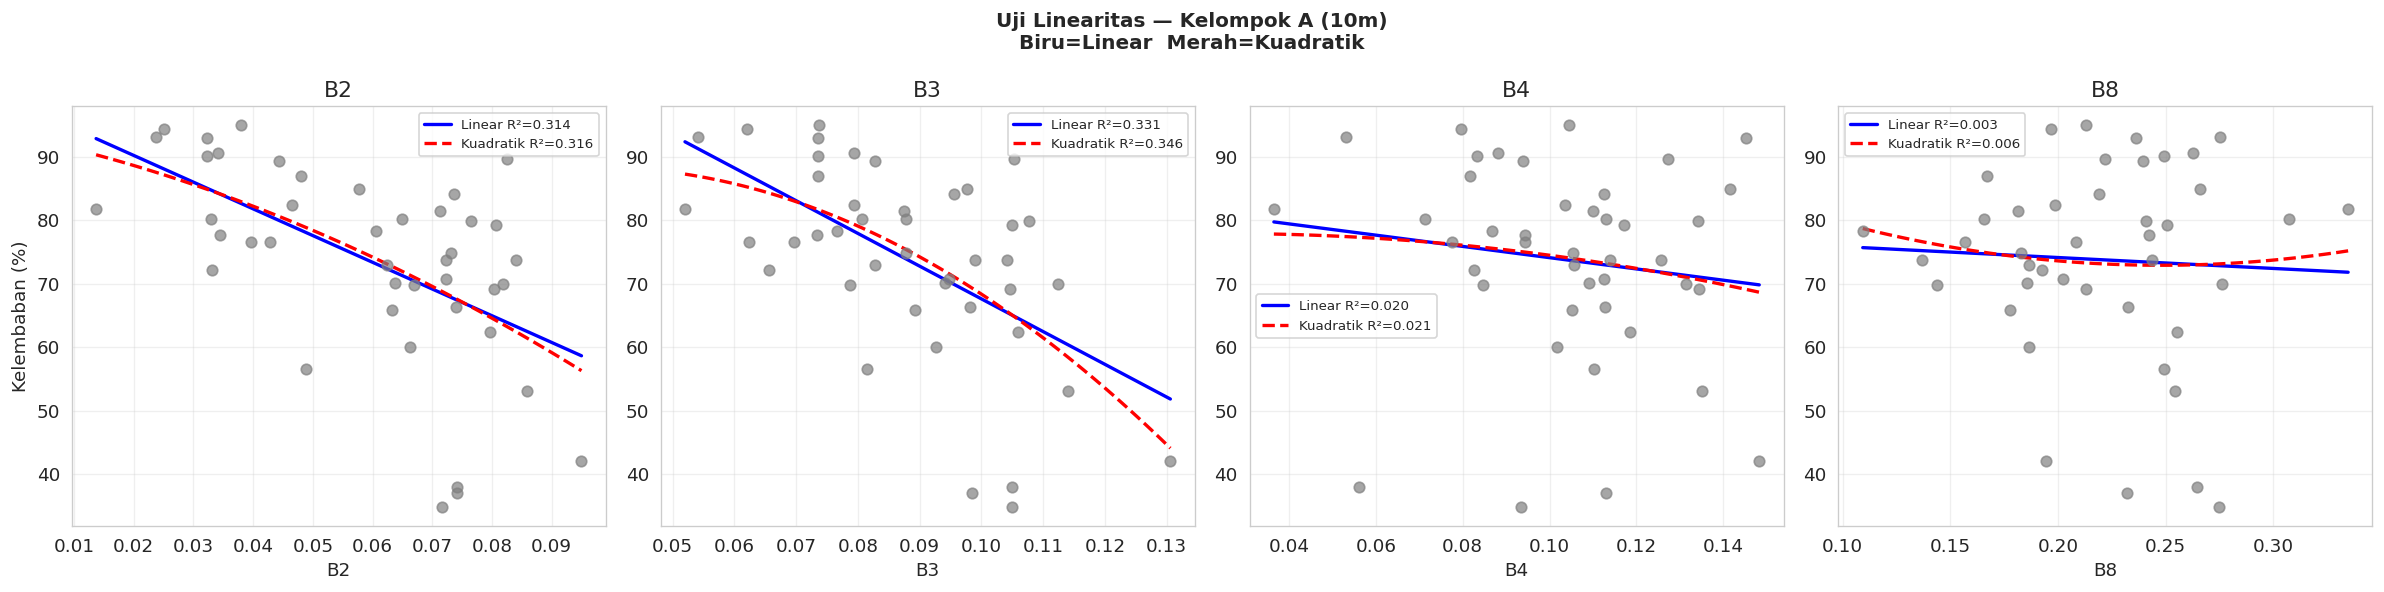

  Tersimpan: plot5B_linearitas_A.png


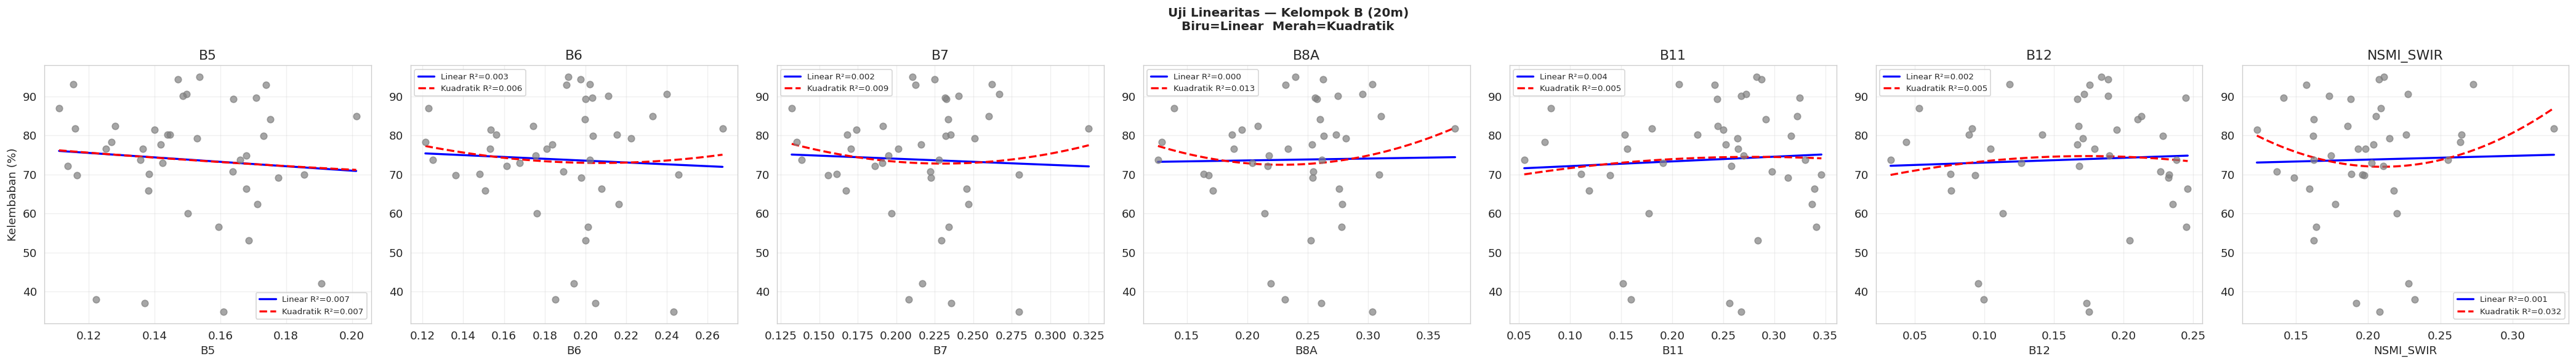

  Tersimpan: plot5B_linearitas_B.png


In [14]:
# -----------------------------------------------------------------------------
# 5B-4. PLOT: Uji Linearitas
# -----------------------------------------------------------------------------

print("\n  [5B-4] Membuat plot uji linearitas...")

fig, axes = plt.subplots(1, len(band_cols_A), figsize=(5*len(band_cols_A), 5))
fig.suptitle("Uji Linearitas — Kelompok A (10m)\nBiru=Linear  Merah=Kuadratik",
             fontsize=12, fontweight='bold')

for i, band in enumerate(band_cols_A):
    ax = axes[i] if len(band_cols_A) > 1 else axes
    x_vals = df_merge_A[band].values
    y_vals = df_merge_A[y_col].values
    x_sort = np.linspace(x_vals.min(), x_vals.max(), 100)
    p1     = np.polyfit(x_vals, y_vals, 1)
    p2     = np.polyfit(x_vals, y_vals, 2)
    r2_lin = r2_score(y_vals, np.polyval(p1, x_vals))
    r2_q   = r2_score(y_vals, np.polyval(p2, x_vals))
    ax.scatter(x_vals, y_vals, alpha=0.7, color='gray', s=40, zorder=3)
    ax.plot(x_sort, np.polyval(p1, x_sort), 'b-',  linewidth=2, label=f'Linear R²={r2_lin:.3f}')
    ax.plot(x_sort, np.polyval(p2, x_sort), 'r--', linewidth=2, label=f'Kuadratik R²={r2_q:.3f}')
    ax.set_xlabel(band)
    ax.set_ylabel("Kelembaban (%)" if i == 0 else "")
    ax.set_title(band)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot5B_linearitas_A.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot5B_linearitas_A.png")

# Kelompok B (termasuk NSMI_SWIR)
band_cols_B_plot = [b for b in band_cols_B_full if b in df_merge_B.columns]
ncols = len(band_cols_B_plot)
fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5))
fig.suptitle("Uji Linearitas — Kelompok B (20m)\nBiru=Linear  Merah=Kuadratik",
             fontsize=12, fontweight='bold')

for i, band in enumerate(band_cols_B_plot):
    ax = axes[i] if ncols > 1 else axes
    x_vals = df_merge_B[band].values
    y_vals = df_merge_B[y_col].values
    x_sort = np.linspace(x_vals.min(), x_vals.max(), 100)
    p1     = np.polyfit(x_vals, y_vals, 1)
    p2     = np.polyfit(x_vals, y_vals, 2)
    r2_lin = r2_score(y_vals, np.polyval(p1, x_vals))
    r2_q   = r2_score(y_vals, np.polyval(p2, x_vals))
    ax.scatter(x_vals, y_vals, alpha=0.7, color='gray', s=40, zorder=3)
    ax.plot(x_sort, np.polyval(p1, x_sort), 'b-',  linewidth=2, label=f'Linear R²={r2_lin:.3f}')
    ax.plot(x_sort, np.polyval(p2, x_sort), 'r--', linewidth=2, label=f'Kuadratik R²={r2_q:.3f}')
    ax.set_xlabel(band)
    ax.set_ylabel("Kelembaban (%)" if i == 0 else "")
    ax.set_title(band)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot5B_linearitas_B.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot5B_linearitas_B.png")

In [15]:
# -----------------------------------------------------------------------------
# 5B-5. Ringkasan tabel korelasi CI & linearitas ke console
# -----------------------------------------------------------------------------
print("\n\n  [5B-5] RINGKASAN KORELASI DENGAN CI")
print("  " + "-"*60)
print(df_ci.to_string(index=False))

print("\n\n  [5B-6] RINGKASAN UJI LINEARITAS")
print("  " + "-"*60)
print(df_linearitas.to_string(index=False))

print("\n\n  IMPLIKASI UNTUK PEMODELAN:")
non_linear_bands = df_linearitas[df_linearitas['Delta_R2'] > 0.05]['Band'].tolist()
if non_linear_bands:
    print(f"  ⚠ Band non-linear: {non_linear_bands}")
    print("    → RF cocok karena menangkap non-linearitas secara otomatis")
    print("    → Ridge (linear) mungkin underfit untuk band ini")
else:
    print("  ✓ Semua band cenderung linear → Ridge dan RF sama-sama valid")



  [5B-5] RINGKASAN KORELASI DENGAN CI
  ------------------------------------------------------------
     Band Kelompok  n  Pearson_r  CI_low  CI_high  p_value Signifikan
       B2  A (10m) 42    -0.5602 -0.7384  -0.3088   0.0001       sig*
       B3  A (10m) 42    -0.5752 -0.7483  -0.3287   0.0001       sig*
       B4  A (10m) 42    -0.1417 -0.4272   0.1696   0.3708         ns
       B8  A (10m) 42    -0.0517 -0.3502   0.2562   0.7448         ns
       B5  B (20m) 42    -0.0823 -0.3768   0.2273   0.6043         ns
       B6  B (20m) 42    -0.0512 -0.3497   0.2567   0.7475         ns
       B7  B (20m) 42    -0.0422 -0.3417   0.2651   0.7908         ns
      B8A  B (20m) 42     0.0164 -0.2890   0.3188   0.9178         ns
      B11  B (20m) 42     0.0619 -0.2467   0.3591   0.6971         ns
      B12  B (20m) 42     0.0479 -0.2598   0.3468   0.7632         ns
NSMI_SWIR  B (20m) 42     0.0252 -0.2809   0.3267   0.8740         ns


  [5B-6] RINGKASAN UJI LINEARITAS
  -------------------

In [16]:
# =============================================================================
# BAGIAN 6: MULTIKOLINEARITAS — VIF
# =============================================================================
print("\n\n[6] MULTIKOLINEARITAS — Variance Inflation Factor (VIF)")
print("-" * 40)
print("  Interpretasi: VIF < 5 = aman, 5-10 = perhatian, > 10 = masalah serius")
print("  (VIF kritis untuk MLR, RF lebih toleran tapi tetap informatif)\n")

def hitung_vif(df, cols, label):
    X = df[cols].dropna()
    vif_data = pd.DataFrame()
    vif_data['Band'] = cols
    vif_data['VIF']  = [variance_inflation_factor(X.values, i) for i in range(len(cols))]
    vif_data['Status'] = vif_data['VIF'].apply(
        lambda v: "✓ Aman" if v < 5 else ("⚠ Perhatian" if v < 10 else "✗ MASALAH")
    )
    print(f"  {label}:")
    print(vif_data.to_string(index=False))
    print()
    return vif_data

vif_A = hitung_vif(df_merge_A, band_cols_A, "Kelompok A (10m) — untuk MLR_A & RF_A")
band_cols_B_vif = band_cols_B + (["NSMI_SWIR"] if "NSMI_SWIR" in df_merge_B.columns else [])
vif_B = hitung_vif(df_merge_B, band_cols_B_vif, "Kelompok B (20m) — untuk MLR_B & RF_B")

print("  ⚠ Jika ada VIF > 10 di Kelompok B: pertimbangkan menghapus satu band")
print("    yang paling berkorelasi, atau gunakan PCA sebelum MLR.")



[6] MULTIKOLINEARITAS — Variance Inflation Factor (VIF)
----------------------------------------
  Interpretasi: VIF < 5 = aman, 5-10 = perhatian, > 10 = masalah serius
  (VIF kritis untuk MLR, RF lebih toleran tapi tetap informatif)

  Kelompok A (10m) — untuk MLR_A & RF_A:
Band        VIF    Status
  B2  97.818026 ✗ MASALAH
  B3 325.265830 ✗ MASALAH
  B4  41.206178 ✗ MASALAH
  B8  40.426407 ✗ MASALAH

  Kelompok B (20m) — untuk MLR_B & RF_B:
     Band         VIF    Status
       B5  137.240999 ✗ MASALAH
       B6 1661.059248 ✗ MASALAH
       B7 3294.375172 ✗ MASALAH
      B8A 1773.966452 ✗ MASALAH
      B11 1303.520812 ✗ MASALAH
      B12  995.754216 ✗ MASALAH
NSMI_SWIR   55.424271 ✗ MASALAH

  ⚠ Jika ada VIF > 10 di Kelompok B: pertimbangkan menghapus satu band
    yang paling berkorelasi, atau gunakan PCA sebelum MLR.




[7] MEMBUAT VISUALISASI...
----------------------------------------


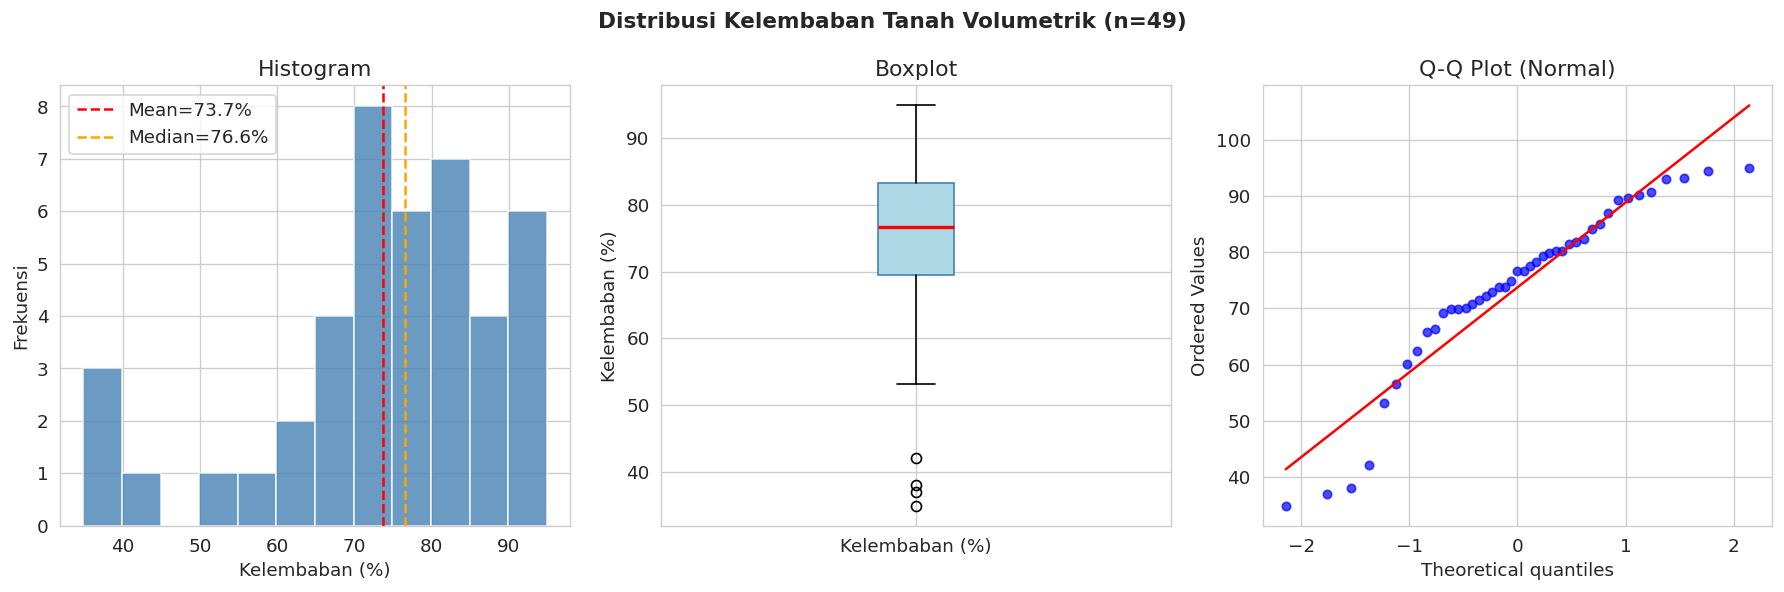

  Tersimpan: plot1_distribusi_kelembaban.png


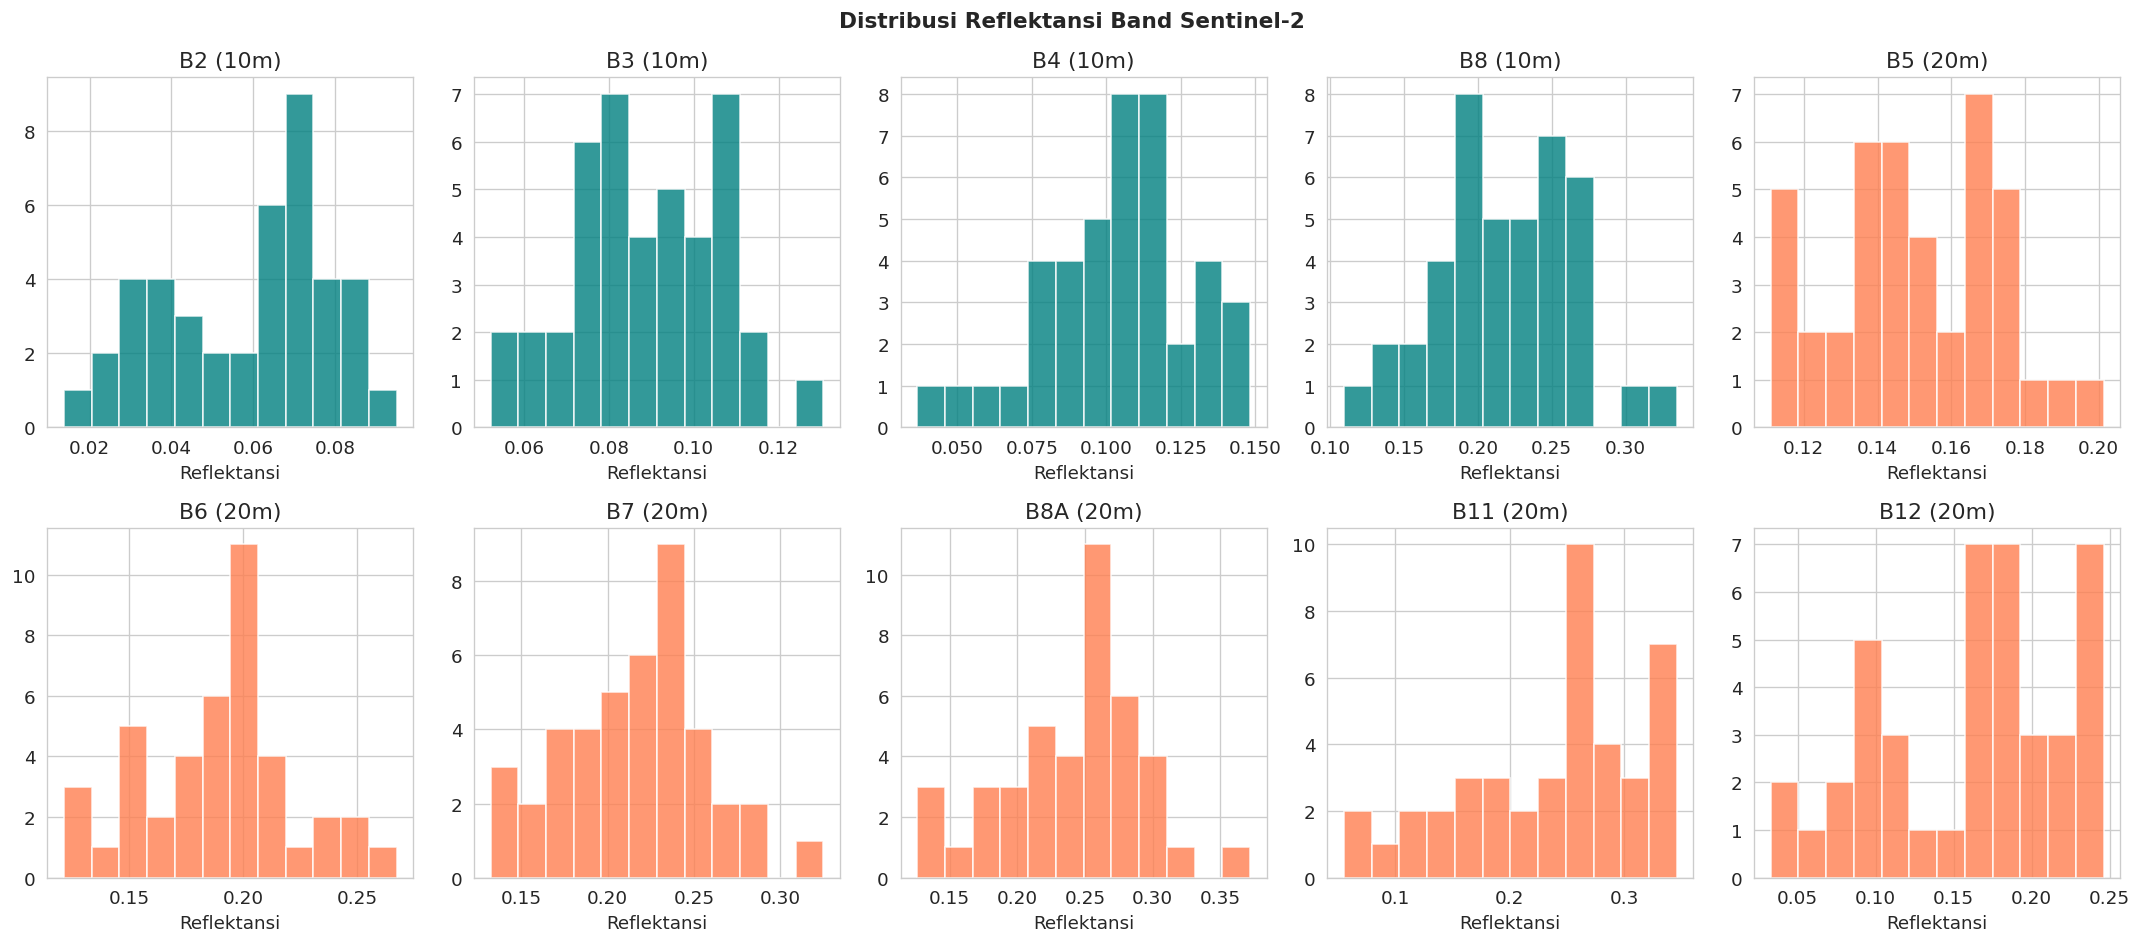

  Tersimpan: plot2_distribusi_band.png


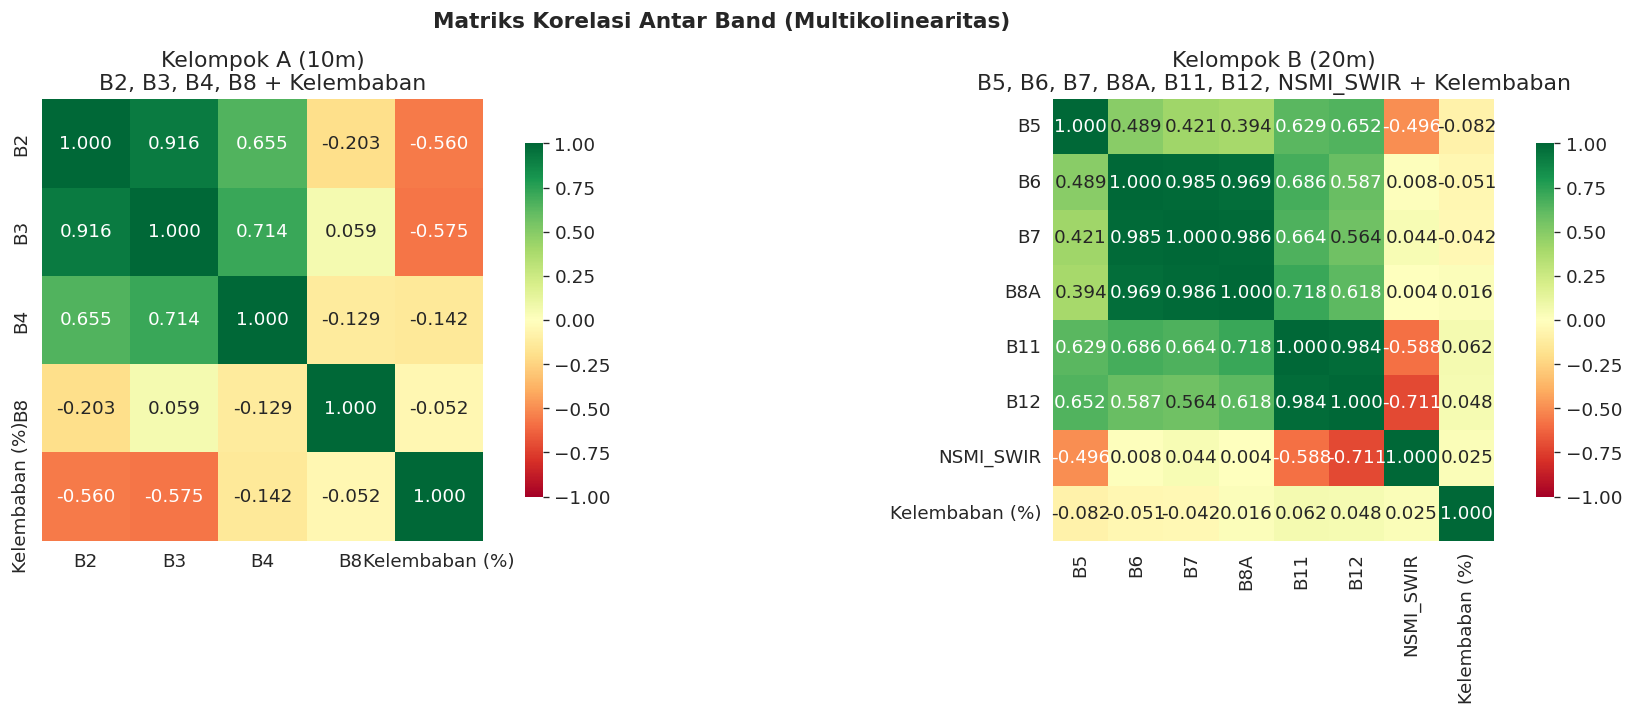

  Tersimpan: plot3_correlation_matrix.png


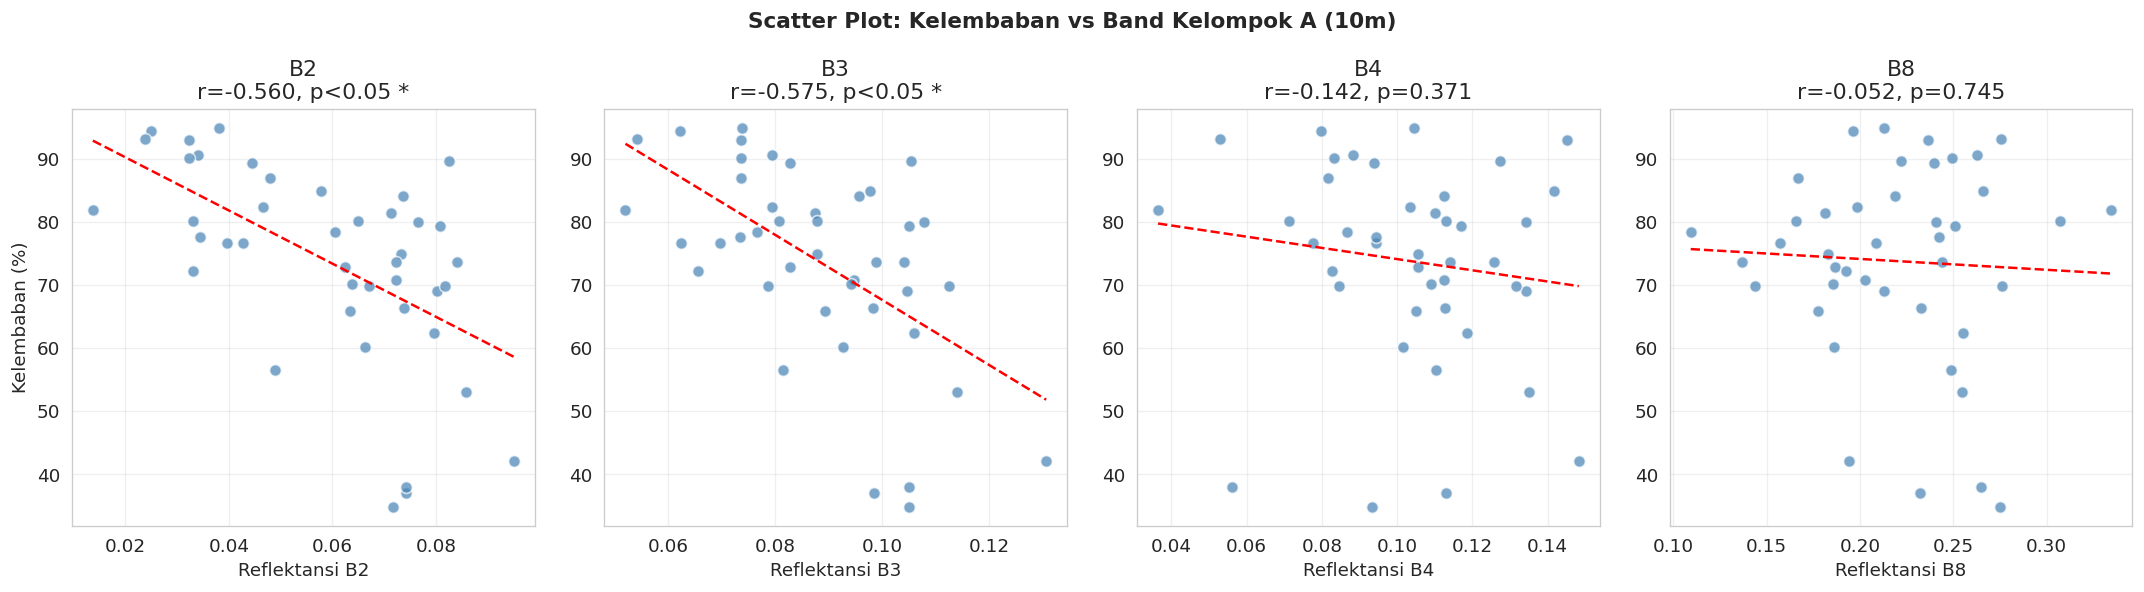

  Tersimpan: plot4_scatter_kelompokA.png


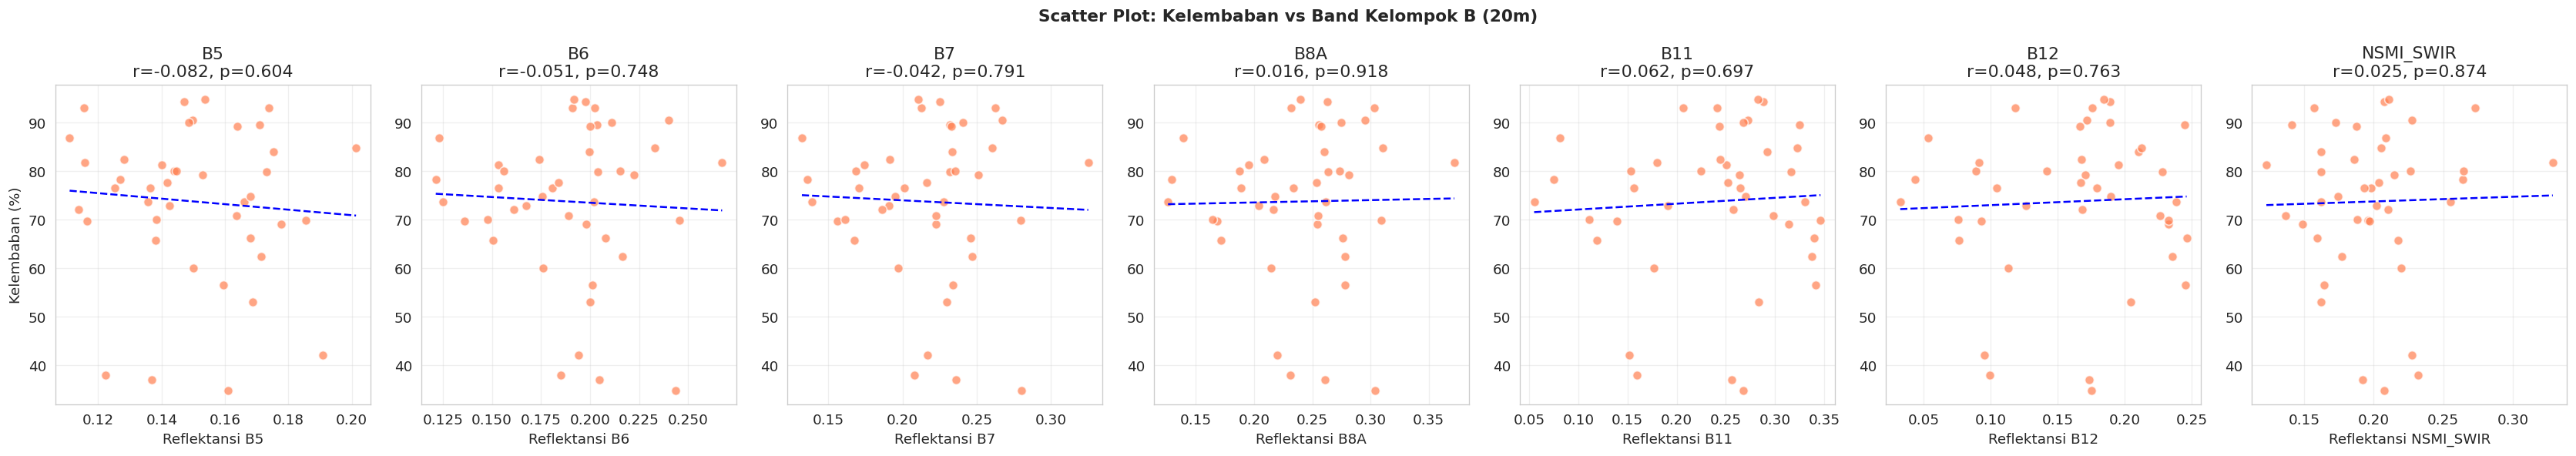

  Tersimpan: plot5_scatter_kelompokB.png


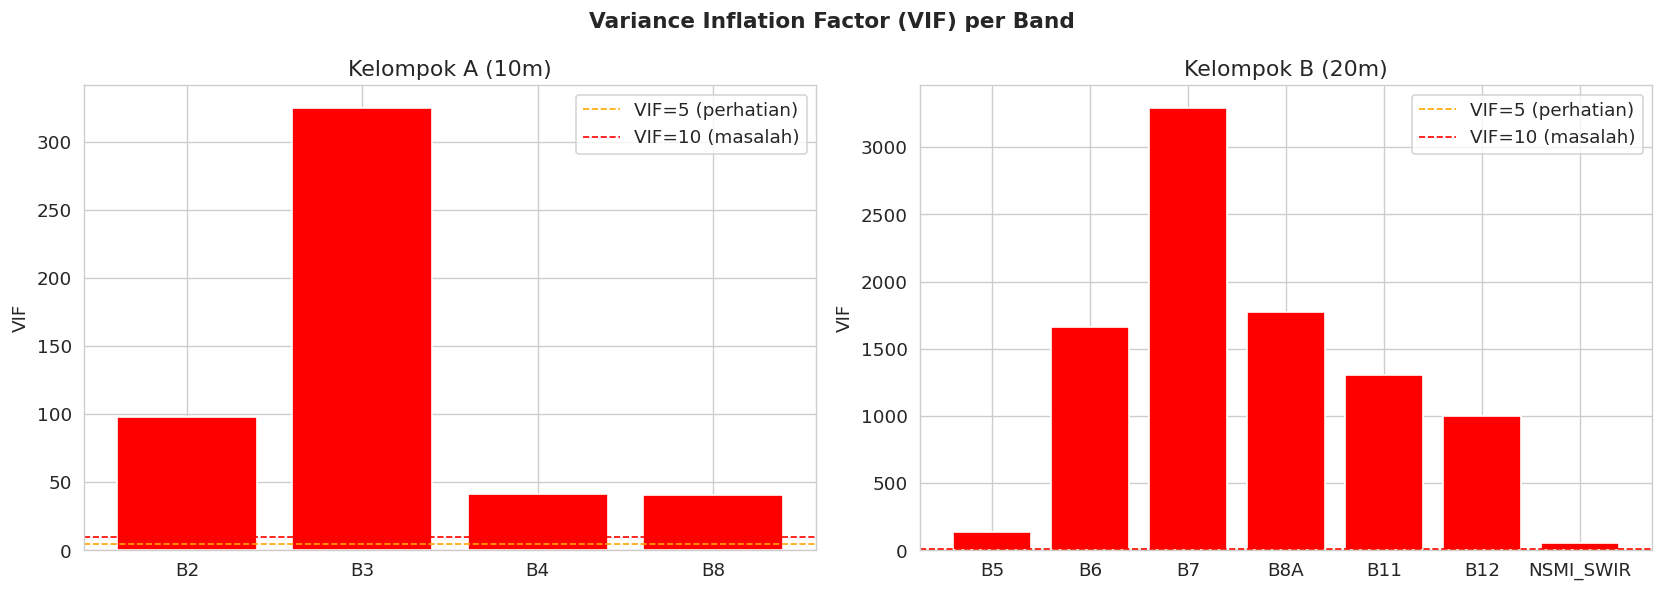

  Tersimpan: plot6_vif.png


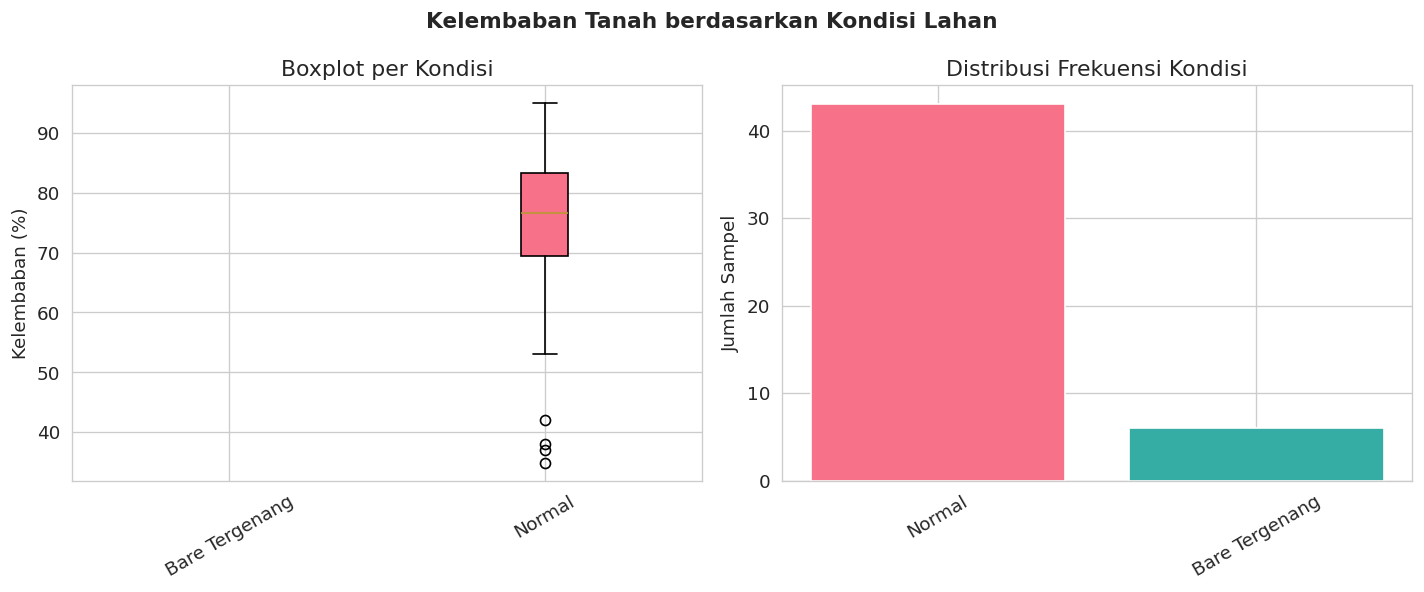

  Tersimpan: plot7_kondisi.png


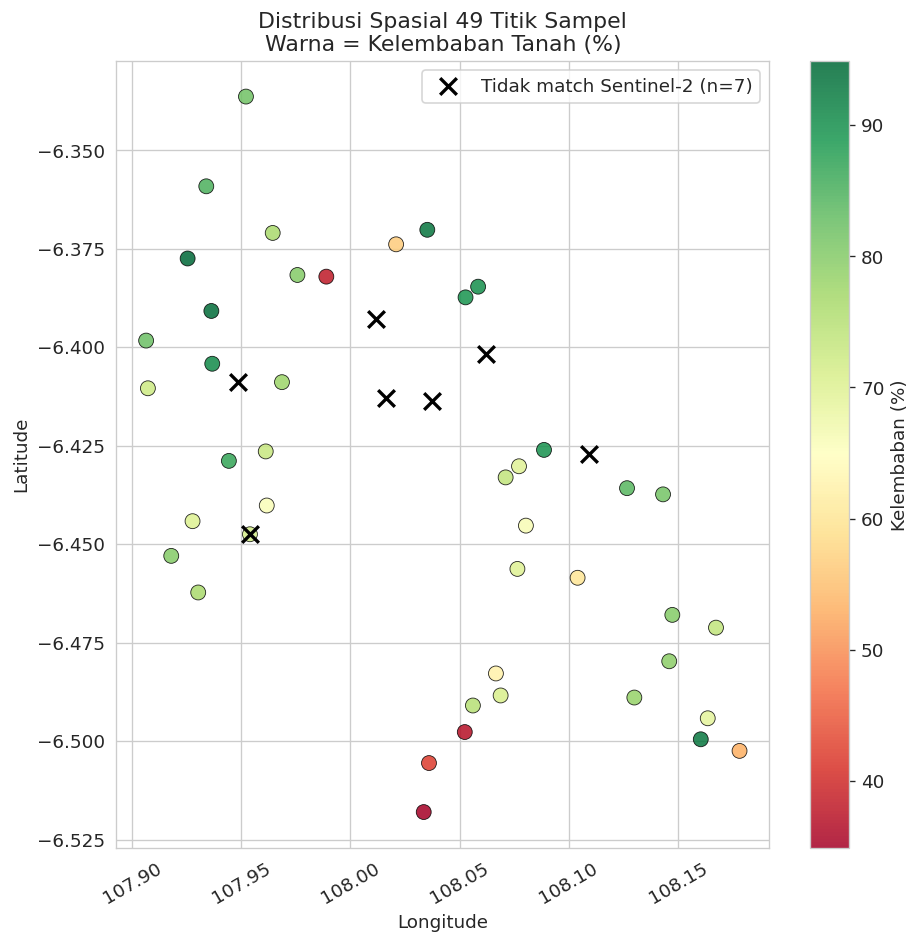

  Tersimpan: plot8_spasial.png


In [17]:
# =============================================================================
# BAGIAN 7: VISUALISASI
# =============================================================================
print("\n\n[7] MEMBUAT VISUALISASI...")
print("-" * 40)

# ----- PLOT 1: Distribusi Y + Boxplot -----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribusi Kelembaban Tanah Volumetrik (n=49)", fontsize=13, fontweight='bold')

axes[0].hist(df_lapangan[y_col], bins=12, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df_lapangan[y_col].mean(), color='red', linestyle='--', label=f"Mean={df_lapangan[y_col].mean():.1f}%")
axes[0].axvline(df_lapangan[y_col].median(), color='orange', linestyle='--', label=f"Median={df_lapangan[y_col].median():.1f}%")
axes[0].set_xlabel("Kelembaban (%)")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Histogram")
axes[0].legend()

axes[1].boxplot(df_lapangan[y_col].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel("Kelembaban (%)")
axes[1].set_title("Boxplot")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["Kelembaban (%)"])

stats.probplot(df_lapangan[y_col].dropna(), dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (Normal)")
axes[2].get_lines()[0].set(markersize=5, alpha=0.7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot1_distribusi_kelembaban.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot1_distribusi_kelembaban.png")


# ----- PLOT 2: Distribusi semua band -----
all_bands = band_cols_A + band_cols_B
df_all_bands = df_merge_B[['fid', y_col] + band_cols_B].merge(
    df_merge_A[['fid'] + band_cols_A], on='fid'
)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Distribusi Reflektansi Band Sentinel-2", fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, band in enumerate(all_bands):
    df_use = df_merge_A if band in band_cols_A else df_merge_B
    data = df_use[band].dropna()
    axes[i].hist(data, bins=12,
                 color='teal' if band in band_cols_A else 'coral',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(f"{band} ({'10m' if band in band_cols_A else '20m'})")
    axes[i].set_xlabel("Reflektansi")

for j in range(len(all_bands), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot2_distribusi_band.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot2_distribusi_band.png")


# ----- PLOT 3: Correlation Matrix (+ NSMI_SWIR) -----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Matriks Korelasi Antar Band (Multikolinearitas)", fontsize=13, fontweight='bold')

corr_A = df_merge_A[band_cols_A + [y_col]].corr()
mask_A = np.zeros_like(corr_A, dtype=bool)
mask_A[np.triu_indices_from(mask_A, k=1)] = True
sns.heatmap(corr_A, ax=axes[0], annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8})
axes[0].set_title("Kelompok A (10m)\nB2, B3, B4, B8 + Kelembaban")

band_cols_B_corr = band_cols_B + (['NSMI_SWIR'] if 'NSMI_SWIR' in df_merge_B.columns else [])
corr_B = df_merge_B[band_cols_B_corr + [y_col]].corr()
sns.heatmap(corr_B, ax=axes[1], annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8})
axes[1].set_title("Kelompok B (20m)\nB5, B6, B7, B8A, B11, B12, NSMI_SWIR + Kelembaban")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot3_correlation_matrix.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot3_correlation_matrix.png")


# ----- PLOT 4: Scatter Plot Kelompok A -----
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Scatter Plot: Kelembaban vs Band Kelompok A (10m)", fontsize=13, fontweight='bold')

for i, band in enumerate(band_cols_A):
    x = df_merge_A[band]
    y = df_merge_A[y_col]
    r, p = stats.pearsonr(x, y)
    axes[i].scatter(x, y, alpha=0.7, color='steelblue', s=50, edgecolors='white')
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(x_line, m*x_line + b, 'r--', linewidth=1.5)
    axes[i].set_xlabel(f"Reflektansi {band}")
    axes[i].set_ylabel("Kelembaban (%)" if i == 0 else "")
    sig = "p<0.05 *" if p < 0.05 else f"p={p:.3f}"
    axes[i].set_title(f"{band}\nr={r:.3f}, {sig}")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot4_scatter_kelompokA.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot4_scatter_kelompokA.png")

# ----- PLOT 5: Scatter Plot Kelompok B (+ NSMI_SWIR) -----
band_cols_B_scatter = band_cols_B + (['NSMI_SWIR'] if 'NSMI_SWIR' in df_merge_B.columns else [])
ncols_B = len(band_cols_B_scatter)
fig, axes = plt.subplots(1, ncols_B, figsize=(4*ncols_B, 5))
axes = [axes] if ncols_B == 1 else list(axes)
fig.suptitle("Scatter Plot: Kelembaban vs Band Kelompok B (20m)", fontsize=13, fontweight='bold')

for i, band in enumerate(band_cols_B_scatter):
    x = df_merge_B[band]
    y = df_merge_B[y_col]
    r, p = stats.pearsonr(x, y)
    axes[i].scatter(x, y, alpha=0.7, color='coral', s=50, edgecolors='white')
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(x_line, m*x_line + b, 'b--', linewidth=1.5)
    axes[i].set_xlabel(f"Reflektansi {band}")
    axes[i].set_ylabel("Kelembaban (%)" if i == 0 else "")
    sig = "p<0.05 *" if p < 0.05 else f"p={p:.3f}"
    axes[i].set_title(f"{band}\nr={r:.3f}, {sig}")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot5_scatter_kelompokB.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot5_scatter_kelompokB.png")


# ----- PLOT 6: VIF Bar Chart -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Variance Inflation Factor (VIF) per Band", fontsize=13, fontweight='bold')

colors_A = ['green' if v < 5 else ('orange' if v < 10 else 'red') for v in vif_A['VIF']]
axes[0].bar(vif_A['Band'], vif_A['VIF'], color=colors_A, edgecolor='white')
axes[0].axhline(5,  color='orange', linestyle='--', linewidth=1, label='VIF=5 (perhatian)')
axes[0].axhline(10, color='red',    linestyle='--', linewidth=1, label='VIF=10 (masalah)')
axes[0].set_title("Kelompok A (10m)")
axes[0].set_ylabel("VIF")
axes[0].legend()

colors_B = ['green' if v < 5 else ('orange' if v < 10 else 'red') for v in vif_B['VIF']]
axes[1].bar(vif_B['Band'], vif_B['VIF'], color=colors_B, edgecolor='white')
axes[1].axhline(5,  color='orange', linestyle='--', linewidth=1, label='VIF=5 (perhatian)')
axes[1].axhline(10, color='red',    linestyle='--', linewidth=1, label='VIF=10 (masalah)')
axes[1].set_title("Kelompok B (20m)")
axes[1].set_ylabel("VIF")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot6_vif.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot6_vif.png")


# ----- PLOT 7: Boxplot per Kondisi -----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Kelembaban Tanah berdasarkan Kondisi Lahan", fontsize=13, fontweight='bold')

kondisi_groups = df_lapangan.groupby('Kondisi')[y_col]
kondisi_names  = list(kondisi_groups.groups.keys())
kondisi_data   = [kondisi_groups.get_group(k).values for k in kondisi_names]

axes[0].boxplot(kondisi_data, labels=kondisi_names, patch_artist=True)
axes[0].set_ylabel("Kelembaban (%)")
axes[0].set_title("Boxplot per Kondisi")
axes[0].tick_params(axis='x', rotation=30)

counts = df_lapangan['Kondisi'].value_counts()
axes[1].bar(counts.index, counts.values, color=sns.color_palette("husl", len(counts)), edgecolor='white')
axes[1].set_ylabel("Jumlah Sampel")
axes[1].set_title("Distribusi Frekuensi Kondisi")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot7_kondisi.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot7_kondisi.png")


# ----- PLOT 8: Scatter Spasial -----
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(df_lapangan['X'], df_lapangan['Y'],
                c=df_lapangan[y_col], cmap='RdYlGn',
                s=80, edgecolors='black', linewidth=0.5, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Kelembaban (%)')

df_hilang = df_lapangan[df_lapangan['fid'].isin(fid_hilang)]
if not df_hilang.empty:
    ax.scatter(df_hilang['X'], df_hilang['Y'],
               c='black', marker='x', s=100, linewidth=2,
               label=f'Tidak match Sentinel-2 (n={len(fid_hilang)})', zorder=5)
    ax.legend()

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Distribusi Spasial 49 Titik Sampel\nWarna = Kelembaban Tanah (%)")
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "plot8_spasial.png", bbox_inches='tight')
plt.show()
print("  Tersimpan: plot8_spasial.png")

In [18]:
# =============================================================================
# BAGIAN 8: RINGKASAN EDA — IMPLIKASI UNTUK PEMODELAN
# =============================================================================
print("\n\n" + "=" * 65)
print("  RINGKASAN EDA — IMPLIKASI UNTUK PEMODELAN")
print("=" * 65)

print(f"""
  DATA:
  • Total sampel lapangan  : 49
  • Sampel valid (match)   : 42 (hilang: {len(fid_hilang)} titik — fid {fid_hilang})
  • Semua 4 model akan dijalankan pada n=42

  VARIABEL Y (KELEMBABAN):
  • Range : {df_lapangan[y_col].min():.1f}% — {df_lapangan[y_col].max():.1f}%
  • Mean  : {df_lapangan[y_col].mean():.2f}%
  • Skewness: {df_lapangan[y_col].skew():.3f}

  PERINGATAN KRITIS:
  • Cek hasil VIF di atas — jika ada VIF > 10, MLR tidak stabil
  • n=42 untuk RF dengan 5-6 prediktor masih terbatas → wajib
    disebutkan sebagai limitasi penelitian
  • 7 sampel tidak match Sentinel-2 → investigasi penyebabnya

  LANGKAH SELANJUTNYA SETELAH EDA:
  1. Bangun 4 model: MLR_A, MLR_B, RF_A, RF_B
  2. Evaluasi: R², RMSE, MAE pada data test (split 80:20 atau LOO-CV)
  3. Bandingkan performa antar skenario
  4. Diskusikan apakah Kelompok A atau B lebih informatif untuk
     kelembaban tanah, dan mengapa secara fisik spektral
""")

print("  Script EDA selesai dijalankan.")
print(f"  Semua plot tersimpan di: {OUTPUT_DIR}")



  RINGKASAN EDA — IMPLIKASI UNTUK PEMODELAN

  DATA:
  • Total sampel lapangan  : 49
  • Sampel valid (match)   : 42 (hilang: 7 titik — fid [18, 25, 29, 40, 43, 46, 49])
  • Semua 4 model akan dijalankan pada n=42

  VARIABEL Y (KELEMBABAN):
  • Range : 34.9% — 94.9%
  • Mean  : 73.72%
  • Skewness: -1.021

  PERINGATAN KRITIS:
  • Cek hasil VIF di atas — jika ada VIF > 10, MLR tidak stabil
  • n=42 untuk RF dengan 5-6 prediktor masih terbatas → wajib
    disebutkan sebagai limitasi penelitian
  • 7 sampel tidak match Sentinel-2 → investigasi penyebabnya

  LANGKAH SELANJUTNYA SETELAH EDA:
  1. Bangun 4 model: MLR_A, MLR_B, RF_A, RF_B
  2. Evaluasi: R², RMSE, MAE pada data test (split 80:20 atau LOO-CV)
  3. Bandingkan performa antar skenario
  4. Diskusikan apakah Kelompok A atau B lebih informatif untuk
     kelembaban tanah, dan mengapa secara fisik spektral

  Script EDA selesai dijalankan.
  Semua plot tersimpan di: /content/drive/MyDrive/Kelembaban_Lapang/EDA/


In [19]:
# -----------------------------------------------------------------------------
# EXPORT RINGKASAN STATISTIK KE EXCEL
# -----------------------------------------------------------------------------
with pd.ExcelWriter(OUTPUT_DIR + "ringkasan_statistik_EDA.xlsx") as writer:
    df_lapangan[[y_col]].describe().T.round(4).to_excel(writer, sheet_name="Deskriptif_Y")
    df_merge_A[band_cols_A].describe().T.round(4).to_excel(writer, sheet_name="Deskriptif_BandA")
    df_merge_B[band_cols_B].describe().T.round(4).to_excel(writer, sheet_name="Deskriptif_BandB")

    corr_rows = []
    for band in band_cols_A:
        r_p, p_p = stats.pearsonr(df_merge_A[band], df_merge_A[y_col])
        r_s, p_s = stats.spearmanr(df_merge_A[band], df_merge_A[y_col])
        corr_rows.append({'Band': band, 'Kelompok': 'A (10m)',
                          'Pearson_r': round(r_p,4), 'Pearson_p': round(p_p,4),
                          'Spearman_r': round(r_s,4), 'Spearman_p': round(p_s,4)})
    band_cols_B_export = band_cols_B + (['NSMI_SWIR'] if 'NSMI_SWIR' in df_merge_B.columns else [])
    for band in band_cols_B_export:
        r_p, p_p = stats.pearsonr(df_merge_B[band], df_merge_B[y_col])
        r_s, p_s = stats.spearmanr(df_merge_B[band], df_merge_B[y_col])
        corr_rows.append({'Band': band, 'Kelompok': 'B (20m)',
                          'Pearson_r': round(r_p,4), 'Pearson_p': round(p_p,4),
                          'Spearman_r': round(r_s,4), 'Spearman_p': round(p_s,4)})
    pd.DataFrame(corr_rows).to_excel(writer, sheet_name="Korelasi_Band_vs_Y", index=False)

    vif_A['Kelompok'] = 'A (10m)'
    vif_B['Kelompok'] = 'B (20m)'
    pd.concat([vif_A, vif_B]).to_excel(writer, sheet_name="VIF", index=False)

    pd.DataFrame({'fid_tidak_match': fid_hilang}).to_excel(
        writer, sheet_name="Sampel_Tidak_Match", index=False)

    # Korelasi dengan CI 95%
    df_ci.to_excel(writer, sheet_name="Korelasi_CI95", index=False)

    # Uji linearitas
    df_linearitas.to_excel(writer, sheet_name="Uji_Linearitas", index=False)

print(f"  Ringkasan Excel tersimpan: {OUTPUT_DIR}ringkasan_statistik_EDA.xlsx")

  Ringkasan Excel tersimpan: /content/drive/MyDrive/Kelembaban_Lapang/EDA/ringkasan_statistik_EDA.xlsx
